# imports

In [1]:
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# muutils
import muutils.tensor_info
from muutils.dbg import dbg, dbg_tensor

# attention-motifs
from attention_motifs.features.analysis import (
	null_stats,
	filter_data,
	normalize_data,
	pca_importance_table,
	aggregate_feature_stats,
	plot_importance_covariance,
)
from attention_motifs.features.plotting import (
	plot_embedding,
	apply_pca,
)

In [2]:
# magic autoreload
%load_ext autoreload
%autoreload 2

In [3]:
# numbers of rows to display
pl.Config.set_tbl_rows(10)
# colored muutils tensor info
muutils.tensor_info.DEFAULT_SETTINGS["colored"] = True
# base path
PATH_BASE: Path = Path("../data/features/")

In [4]:
# raw data from file instead of regenerating
DATA_RAW = pl.read_ndjson(PATH_BASE / "raw.jsonl")

# basic data inspection

In [5]:
# display(DATA_RAW)
# display(set(DATA_RAW.dtypes))
# display(DATA_RAW.head())
# display(DATA_RAW.describe())
# print(f"{DATA_RAW['activation.model'].unique() = }")
# for col in DATA_RAW.columns:
# 	if col.startswith("activation"):
# 		print(f"{col = }")
display(null_stats(DATA_RAW))

feature,missing_count,missing_frac
str,i64,f64
"""feat.markov_transition.time.sk…",123043,0.993308
"""feat.markov_transition.time.ku…",123043,0.993308
"""feat.markov_transition.env.upp…",0,0.0
"""feat.log.gram.col.beta_hist.hi…",0,0.0
"""feat.first_tok.entropy""",0,0.0
…,…,…
"""feat.markov_transition.diff.li…",0,0.0
"""feat.diag.linreg.r2""",0,0.0
"""feat.diag.L1_norm""",0,0.0


# filter nans and certain models

In [6]:
# this will filter all-nan rows
DATA_FILTERED: pl.DataFrame = filter_data(
	DATA_RAW,
	# tinystories and small pythia models look very different in embedding space, so we get rid of them
	remove_models=["tiny-stories-1M", "pythia-14m"],
)
null_stats(DATA_FILTERED)

Removing 2 models: ['tiny-stories-1M', 'pythia-14m']
Removed 19456/123872 rows
Removing 37/176 feat.* columns due to zero variance or excessive missing values
feat.markov_transition.env.upper.slope                       μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.markov_transition.time.autocorr_lag1                    μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.markov_transition.time.psd_total_power                  μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.markov_transition.env.upper.r2                          μ=1.00 σ=0.00 x̃=1.00 R=[1.00,1.00] shape=104416 dtype=float64
feat.markov_transition.time.zero_crossing_rate               μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.log.gram.col.beta_hist.hist.raw.zero_crossing_rate      μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.gram.skew.beta_hist.hist.raw.zero_crossing_rate         μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] 

feature,missing_count,missing_frac
str,i64,f64
"""feat.log.gram.col.beta_hist.hi…",0,0.0
"""feat.first_tok.entropy""",0,0.0
"""feat.log.gram.row.beta_hist.hi…",0,0.0
"""feat.first_tok.psd_total_power""",0,0.0
"""feat.markov_transition.diff.ps…",0,0.0
…,…,…
"""feat.markov_transition.diff.li…",0,0.0
"""feat.diag.linreg.r2""",0,0.0
"""feat.diag.L1_norm""",0,0.0


# scaling

In [7]:
FEATURE_COLS: list[str] = [
	col for col in DATA_FILTERED.columns if col.startswith("feat.")
]
DATA_SCALED: pl.DataFrame
DATA_NORMS: pl.DataFrame
DATA_SCALED, DATA_NORMS = normalize_data(DATA_FILTERED, FEATURE_COLS)
DATA_NORMS.write_ndjson(PATH_BASE / "scaling.jsonl")
# display(DATA_SCALED)
display(null_stats(DATA_SCALED))
DATA_SCALED.write_ndjson(PATH_BASE / "scaled.jsonl")

feature,missing_count,missing_frac
str,i64,f64
"""feat.log.gram.col.beta_hist.hi…",0,0.0
"""feat.first_tok.entropy""",0,0.0
"""feat.log.gram.row.beta_hist.hi…",0,0.0
"""feat.first_tok.psd_total_power""",0,0.0
"""feat.markov_transition.diff.ps…",0,0.0
…,…,…
"""feat.markov_transition.diff.li…",0,0.0
"""feat.diag.linreg.r2""",0,0.0
"""feat.diag.L1_norm""",0,0.0


In [8]:
# plot_correlation_matrix(
# 	DATA_SCALED,
# 	FEATURE_COLS,
# 	sort_by="var",
# )

# PCA

[ <ipykernel>:2 ] DATA_SCALED[FEATURE_COLS].to_numpy(): μ=-0.00 σ=1.00 x̃=-0.16 R=[-16.09,25.89] ℙ=|  █    | shape=(104416,139) dtype=float64


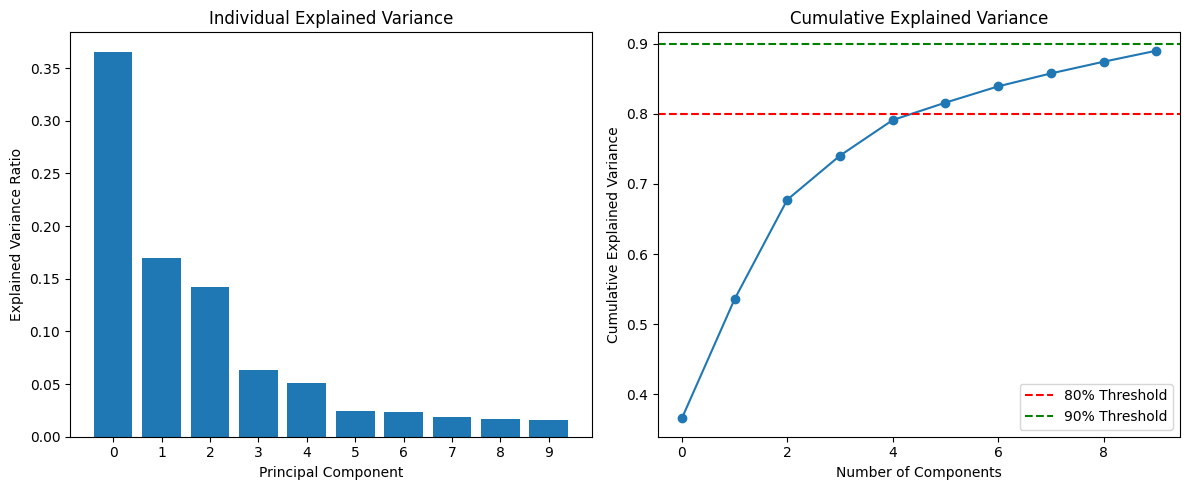

Number of components: 10
Total explained variance: 0.8901
Components needed for 80% variance: 6
Components needed for 90% variance: 1


[ <ipykernel>:7 ] PCA_DATA: μ=0.00 σ=3.52 x̃=-0.07 R=[-35.88,27.20] ℙ=|   █▆  | shape=(104416,10) dtype=float64
[ <ipykernel>:16 ] len(FEATURE_COLS) = 139
[ <ipykernel>:17 ] PCA_OBJ.components_: μ=0.01 σ=0.08 x̃=0.00 R=[-0.30,0.31] ℙ=|  ▄█▃▁ | shape=(10,139) dtype=float64


In [9]:
# PCA
dbg_tensor(DATA_SCALED[FEATURE_COLS].to_numpy())
PCA_DATA: np.ndarray
PCA_OBJ: PCA
PCA_DATA, PCA_OBJ = apply_pca(DATA_SCALED, n_components=10, feature_cols=FEATURE_COLS)
# save pca data
dbg_tensor(PCA_DATA)
np.save(PATH_BASE / "pca.npy", PCA_DATA)

# only columns that start with "activation."
# for labelling the PCA plot in the webapp
data_meta: pl.DataFrame = DATA_SCALED[
	[col for col in DATA_SCALED.columns if col.startswith("activation.")]
]
data_meta.write_ndjson(PATH_BASE / "meta.jsonl")
dbg(len(FEATURE_COLS))
dbg_tensor(PCA_OBJ.components_)

# pca and meta in one dataframe
pca_cols: list[str] = [f"pc.{i}" for i in range(PCA_DATA.shape[1])]
DF_PCA: pl.DataFrame = pl.DataFrame(PCA_DATA, schema=pca_cols)
DF_PCA = pl.concat([DF_PCA, data_meta], how="horizontal")
DF_PCA.write_ndjson(PATH_BASE / "pca.jsonl")

In [10]:
df_importance: pl.DataFrame = pca_importance_table(
	PCA_OBJ,
	feature_names=FEATURE_COLS,
)
df_importance.sort(pl.col("PC0").abs(), descending=True)

feature,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,abs_mean,abs_max,abs_var,var_weighted
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""feat.log.gram.col.beta_hist.hi…",0.132019,0.021744,0.041693,0.026644,0.050231,-0.039893,0.007525,-0.042993,0.002443,-0.043938,0.040912,0.132019,0.001157,0.064796
"""feat.log.gram.col.beta_hist.hi…",-0.131491,-0.023885,-0.029988,-0.027592,-0.058581,0.043806,-0.008661,0.040766,0.002672,0.049681,0.041712,0.131491,0.001168,0.063965
"""feat.log.gram.col.beta_hist.hi…",-0.130876,-0.018614,-0.028844,-0.032396,-0.062058,0.052676,-0.013077,0.043954,0.004689,0.046901,0.043409,0.130876,0.001146,0.063533
"""feat.log.gram.col.beta_hist.hi…",-0.130754,-0.016101,-0.057749,-0.021995,-0.035636,0.02978,0.002459,0.037141,-0.029938,0.037038,0.039859,0.130754,0.00111,0.064495
"""feat.log.gram.col.beta_hist.hi…",-0.12954,-0.02547,-0.019496,-0.0281,-0.065156,0.046702,-0.009547,0.038372,0.007077,0.054098,0.042356,0.12954,0.001163,0.062588
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""feat.gram.row.beta_hist.hist.r…",0.002865,-0.023512,-0.053345,-0.061836,0.314323,0.03835,0.091534,0.028331,0.058157,-0.006211,0.067846,0.314323,0.007407,0.03711
"""feat.first_tok.variance""",0.002493,-0.045873,-0.002241,-0.088058,0.195627,0.085487,0.200255,-0.030599,0.248453,0.280905,0.117999,0.280905,0.009788,0.040381
"""feat.first_tok.std""",-0.001762,-0.051413,-0.011455,-0.088231,0.21202,0.067212,0.202844,-0.033565,0.248602,0.265173,0.118228,0.265173,0.009465,0.042622


In [11]:
display(aggregate_feature_stats(df_importance, side=1).sort("max", descending=True))

token,mean,min,max,median
str,f64,f64,f64,f64
"""first_tok""",0.075287,0.049504,0.118228,0.06668
"""gram""",0.06981,0.03859,0.100537,0.07101
"""log""",0.05608,0.038113,0.100355,0.055813
"""diag""",0.081186,0.066255,0.091967,0.081856
"""markov_transition""",0.047135,0.038061,0.080438,0.042245


/home/miv/projects/attn/attention-motifs/attention_motifs/features/analysis.py:406: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


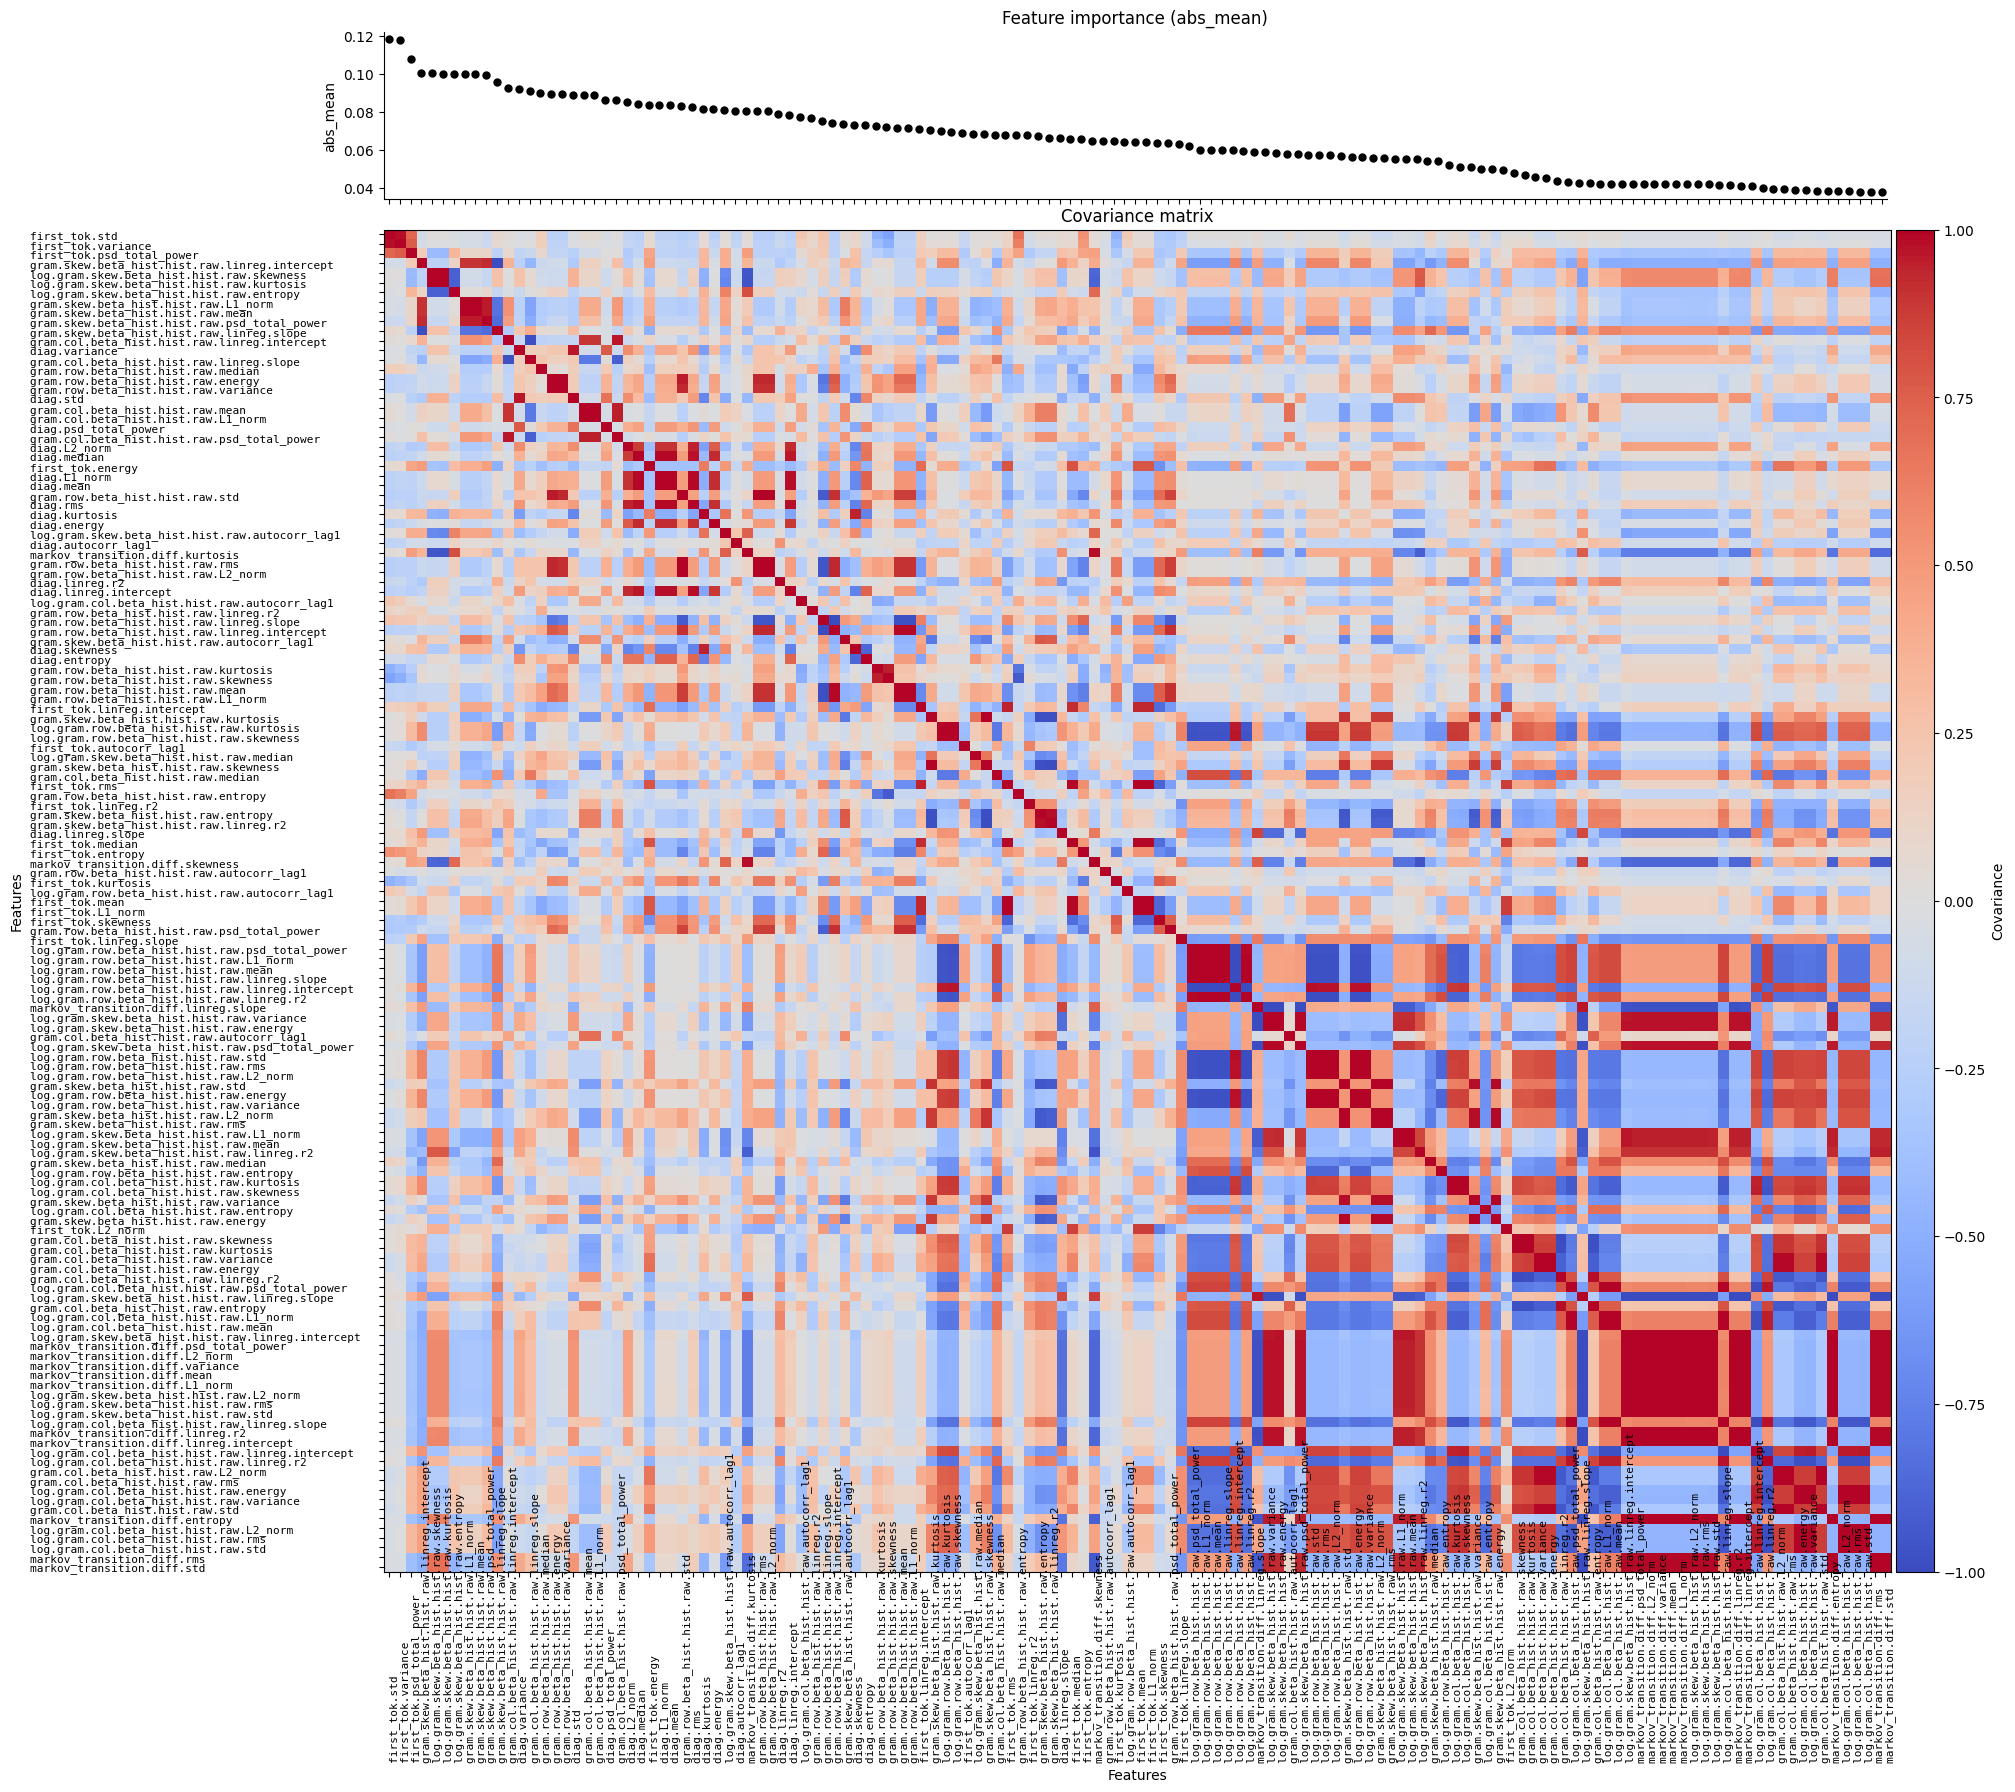

In [ ]:
cov_feats, cov_mat = plot_importance_covariance(
	DATA_SCALED,
	df_importance,
	# feature_order=sorted(FEATURE_COLS, key=lambda x: x.split(".")[-1]),
	metric="abs_mean",
	descending=True,
	cmap="coolwarm",
	figsize=(20, 20),
)

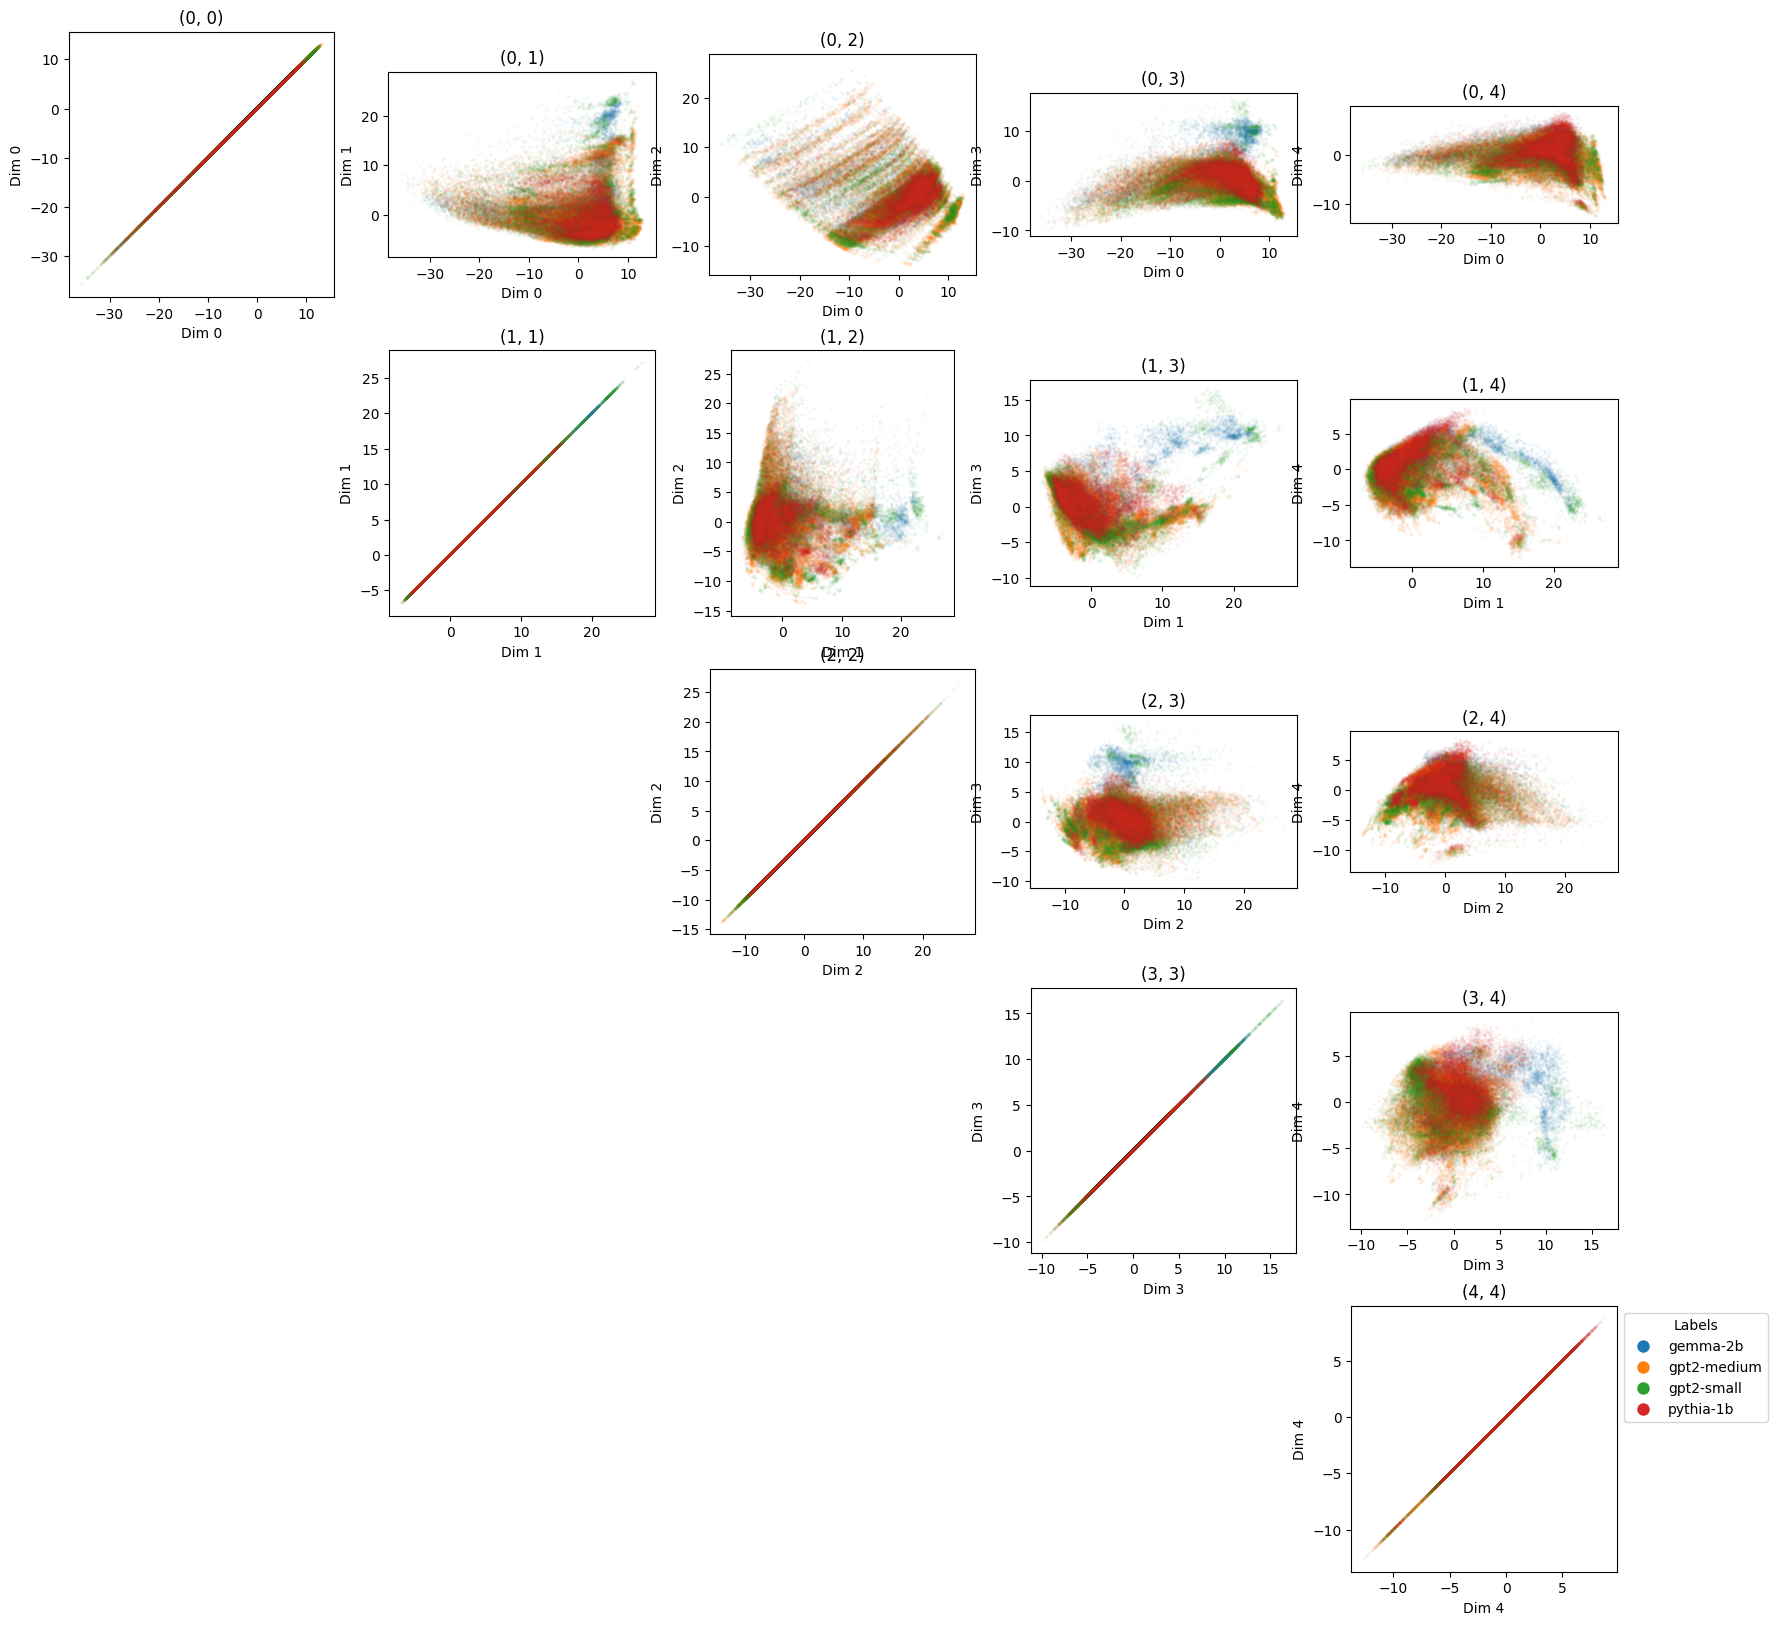

In [13]:
# DATA_REDUCED: pl.DataFrame = DATA_SCALED.select(
# 	[
# 		f for f in DATA_SCALED.columns
# 		if "markov_transition" not in f
# 	]
# )

n_dims: int = 5
embed_fig, embed_ax = plt.subplots(
	n_dims,
	n_dims,
	figsize=(20, 20),
)
for i in range(0, n_dims):
	for j in range(i, n_dims):
		plot_embedding(
			PCA_DATA,
			DATA_SCALED["activation.model"],
			(i, j),
			alpha=0.05,
			marker_size=5,
			title=f"({i}, {j})",
			ax=embed_ax[i, j],
		)
	for k in range(0, i):
		embed_ax[i, k].axis("off")

In [14]:
DATA_SCALED

feat.log.gram.col.beta_hist.hist.raw.energy,feat.first_tok.entropy,feat.log.gram.row.beta_hist.hist.raw.psd_total_power,feat.first_tok.psd_total_power,feat.markov_transition.diff.psd_total_power,feat.log.gram.row.beta_hist.hist.raw.entropy,feat.gram.col.beta_hist.hist.raw.linreg.r2,feat.log.gram.row.beta_hist.hist.raw.energy,feat.gram.skew.beta_hist.hist.raw.linreg.r2,feat.first_tok.autocorr_lag1,feat.log.gram.skew.beta_hist.hist.raw.linreg.slope,feat.log.gram.row.beta_hist.hist.raw.std,feat.gram.row.beta_hist.hist.raw.linreg.r2,feat.log.gram.col.beta_hist.hist.raw.linreg.r2,feat.log.gram.skew.beta_hist.hist.raw.kurtosis,activation.prompt,feat.gram.skew.beta_hist.hist.raw.std,feat.log.gram.skew.beta_hist.hist.raw.skewness,feat.log.gram.skew.beta_hist.hist.raw.linreg.r2,feat.first_tok.linreg.intercept,feat.markov_transition.diff.entropy,feat.gram.col.beta_hist.hist.raw.linreg.slope,feat.gram.row.beta_hist.hist.raw.linreg.intercept,feat.gram.col.beta_hist.hist.raw.std,feat.diag.median,feat.log.gram.col.beta_hist.hist.raw.std,feat.log.gram.skew.beta_hist.hist.raw.std,feat.log.gram.row.beta_hist.hist.raw.linreg.r2,feat.first_tok.linreg.slope,feat.diag.skewness,feat.first_tok.std,feat.diag.L2_norm,feat.gram.col.beta_hist.hist.raw.entropy,feat.gram.skew.beta_hist.hist.raw.skewness,feat.gram.skew.beta_hist.hist.raw.linreg.slope,feat.log.gram.row.beta_hist.hist.raw.variance,feat.log.gram.skew.beta_hist.hist.raw.entropy,…,feat.log.gram.col.beta_hist.hist.raw.autocorr_lag1,feat.gram.col.beta_hist.hist.raw.rms,feat.first_tok.mean,feat.gram.row.beta_hist.hist.raw.kurtosis,feat.log.gram.col.beta_hist.hist.raw.variance,feat.gram.row.beta_hist.hist.raw.energy,feat.log.gram.row.beta_hist.hist.raw.skewness,feat.log.gram.row.beta_hist.hist.raw.linreg.intercept,feat.log.gram.col.beta_hist.hist.raw.entropy,feat.diag.energy,feat.gram.col.beta_hist.hist.raw.median,feat.gram.col.beta_hist.hist.raw.L2_norm,feat.gram.col.beta_hist.hist.raw.linreg.intercept,activation.cache_key,feat.log.gram.col.beta_hist.hist.raw.skewness,feat.gram.row.beta_hist.hist.raw.std,feat.first_tok.variance,feat.log.gram.skew.beta_hist.hist.raw.median,feat.log.gram.col.beta_hist.hist.raw.mean,feat.diag.autocorr_lag1,feat.gram.col.beta_hist.hist.raw.psd_total_power,feat.gram.skew.beta_hist.hist.raw.kurtosis,feat.gram.skew.beta_hist.hist.raw.linreg.intercept,feat.gram.skew.beta_hist.hist.raw.mean,feat.gram.col.beta_hist.hist.raw.energy,feat.gram.col.beta_hist.hist.raw.mean,feat.log.gram.skew.beta_hist.hist.raw.energy,feat.gram.row.beta_hist.hist.raw.autocorr_lag1,feat.gram.col.beta_hist.hist.raw.L1_norm,feat.log.gram.row.beta_hist.hist.raw.kurtosis,feat.diag.linreg.intercept,feat.diag.variance,feat.markov_transition.diff.linreg.r2,feat.diag.linreg.r2,feat.diag.L1_norm,feat.log.gram.col.beta_hist.hist.raw.psd_total_power,feat.first_tok.skewness
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.989938,0.604305,-0.687398,0.489934,-0.266285,-0.682661,-0.792824,0.862457,-1.11468,-1.946191,0.210352,0.836533,0.87097,-0.863237,0.346838,"""MjWkadUxH4Z5nfLEFtUc1w""",1.023283,0.339087,0.175968,0.155735,-0.245457,0.159702,-0.283626,0.878836,-0.002193,0.967734,-0.277801,-0.735166,0.310588,-1.217447,0.833364,0.28935,-1.024035,1.141701,0.060201,0.86094,-0.339936,…,-1.580293,0.870882,0.24403,-0.604601,0.988711,-0.238897,0.493229,0.724929,-0.967268,0.065533,-0.552569,0.870882,-0.337689,"""blocks.0.attn.hook_pattern""",0.659782,-0.340838,0.776566,1.532475,-0.818746,-0.451801,-0.465602,1.183586,-0.252545,-0.692114,0.892255,-0.688287,-0.30592,-0.554036,-0.688287,0.473904,0.045931,1.435507,-0.264634,-0.986983,0.204746,-0.780488,-0.631021
1.070734,0.678459,-0.687398,1.947786,-0.266285,-0.682661,-0.988625,0.862457,-1.34125,-2.216734,0.251842,0.836533,1.890